# 03 - Simulation: random walks, cover and mixing time

In this notebook we use simulations to build intuition for two ideas: **mixing time** and **cover time**.

To motivate the random walk, imagine the following story. One student in the MatCAD class somehow knows the exact exam questions of the course of *Modelització i Simulació*. Every hour, the student who currently has that information tells it to **one** of their friends, chosen uniformly at random among their neighbours in the class network.

This is not a massive diffusion model where many students spread the rumour at the same time. It is a **single piece of information** being passed from student to student, so it is exactly a random walk on the graph.

We will compare three possible friendship structures:

- `ring`: friendships are very local and ordered.
- `ws`: mostly local friendships, but with a few shortcuts.
- `er`: a much more random friendship pattern.

With this interpretation, the two questions become very natural:

1. After many hours, does it still matter which student had the secret at the beginning? This is the **mixing time**.
2. How many hours do we need until the secret has passed through the whole class at least once? This is the **cover time**.

## 1. Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

MAPPING_NAMES = {
    "ring": "Ring lattice",
    "er": "Erdos-Renyi",
    "ws": "Watts-Strogatz",
}

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import Markdown, display

from src.smallworld.networks import build_all
from src.smallworld.plotting import (
    draw_networks_grid,
    plot_cover_time,
    plot_mixing_time_distribution,
)
from src.smallworld.simulation import (
    build_transition_matrix,
    cover_time,
    mixing_time,
    random_walk,
    stationary_distribution,
)


def largest_component_graph(G):
    """Use the giant component when a random graph is disconnected."""
    if nx.is_connected(G):
        return G.copy()
    main_nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(main_nodes).copy()


## 2. Introduction: the exam secret as a random walk

Under our story, the random walker is simply **the secret itself**.

The node is the student that currently holds the information; one step means one hour passes. Therefore next node is the friend chosen to receive the secret.

So a random walk is just the sequence of students that successively hold the exam secret.

The transition matrix `P` stores that rule:

- column `j`: student who currently has the secret,
- row `i`: student who receives it next,
- entry `P[i, j]`: probability that student `j` tells student `i` in the next hour.

Each column sums to 1 because, after one hour, the secret must be passed to exactly one neighbour (otherwise, which kind of friendship is that?).

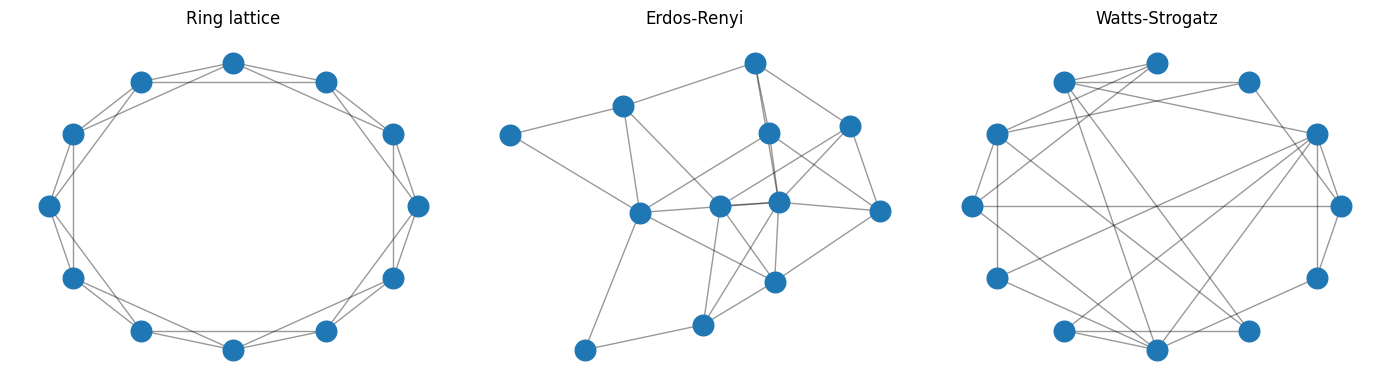

Example: who has the exam secret each hour in the Watts-Strogatz class
hour  0: student 0
hour  1: student 6
hour  2: student 9
hour  3: student 4
hour  4: student 1
hour  5: student 7
hour  6: student 1
hour  7: student 4
hour  8: student 3
hour  9: student 4
hour 10: student 3
hour 11: student 4
hour 12: student 1


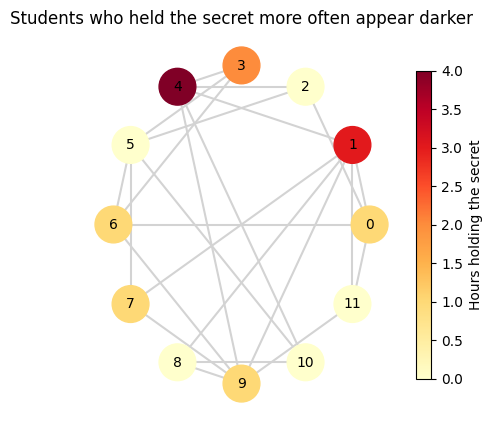

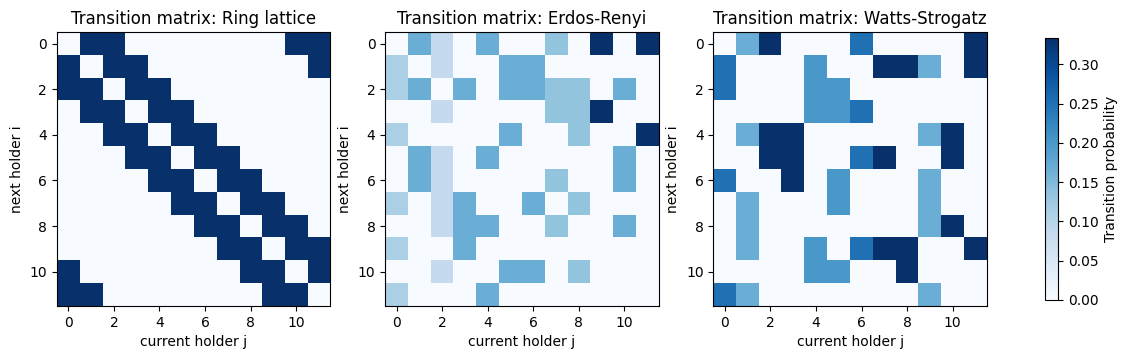

In [2]:
SEED = 7 # for reproducibility
N_intro, k_intro, beta_intro = 12, 4, 0.20
graphs_intro = build_all(N=N_intro, k=k_intro, beta=beta_intro, seed=SEED)

fig = draw_networks_grid(
    graphs_intro,
    titles=MAPPING_NAMES,
    node_size=220,
    figsize=(14, 4),
    seed=SEED,
)
plt.show()

walk_graph = graphs_intro["ws"]
start_student = 0
n_hours = 12
trace = [start_student] + random_walk(walk_graph, start=start_student, n_steps=n_hours, rng=SEED)

print("Example: who has the exam secret each hour in the Watts-Strogatz class")
for hour, student in enumerate(trace):
    print(f"hour {hour:>2}: student {student}")

# calculate how many times each student had the exam
visit_counts = {node: trace.count(node) for node in walk_graph.nodes()}
node_colors = [visit_counts.get(node, 0) for node in walk_graph.nodes()]
pos = nx.circular_layout(walk_graph)

# plot for visualization
fig, ax = plt.subplots(figsize=(5, 5))
nx.draw_networkx_edges(walk_graph, pos, ax=ax, edge_color="lightgray", width=1.5)
nodes = nx.draw_networkx_nodes(
    walk_graph,
    pos,
    ax=ax,
    node_color=node_colors, # if darker => student held the secret more often
    cmap="YlOrRd",
    node_size=700,
)
nx.draw_networkx_labels(walk_graph, pos, ax=ax, font_size=10)
ax.set_title("Students who held the secret more often appear darker")
ax.axis("off")
plt.colorbar(nodes, ax=ax, shrink=0.8, label="Hours holding the secret")
plt.show()

# draw the transition matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
last_im = None
for ax, (name, graph) in zip(axes, graphs_intro.items()):
    P, _ = build_transition_matrix(graph)
    last_im = ax.imshow(P, cmap="Blues", vmin=0, vmax=P.max())
    ax.set_title(f"Transition matrix: {MAPPING_NAMES[name]}")
    ax.set_xlabel("current holder j")
    ax.set_ylabel("next holder i")

fig.colorbar(last_im, ax=axes, shrink=0.85, label="Transition probability")
plt.show()


The **key idea** is the following one: in the ring, the secret tends to move locally; in ER it can jump in a much less structured way; but WS sits in between, preserving neighbourhood structure but adding a few useful shortcuts."

## 3. Mixing time

The **mixing time** measures how many hours the process needs to practically forget who had the secret at the beginning.

Intuition:

- In a `ring`, the secret moves locally, so it keeps some memory of where it started for longer. If student A is really distant to student Z, the hours that will pass until the secret arrives to student Z will be longer, since the "friendships" are local.
- In `ws`, a few shortcuts should reduce that memory quite a lot. There are some really popular students, which may be the bridge between students.
- In `er`, the holder of the secret should become hard to predict relatively quickly, since each student is randomly friend with the other students of the class.

In the next cell, change `beta_to_try` and rerun the experiment to observe how the mixing time depends on this parameter. Observe that when `beta_to_try` apporximates to zero, the mixing time distribution is practically the same as the `ring` network.

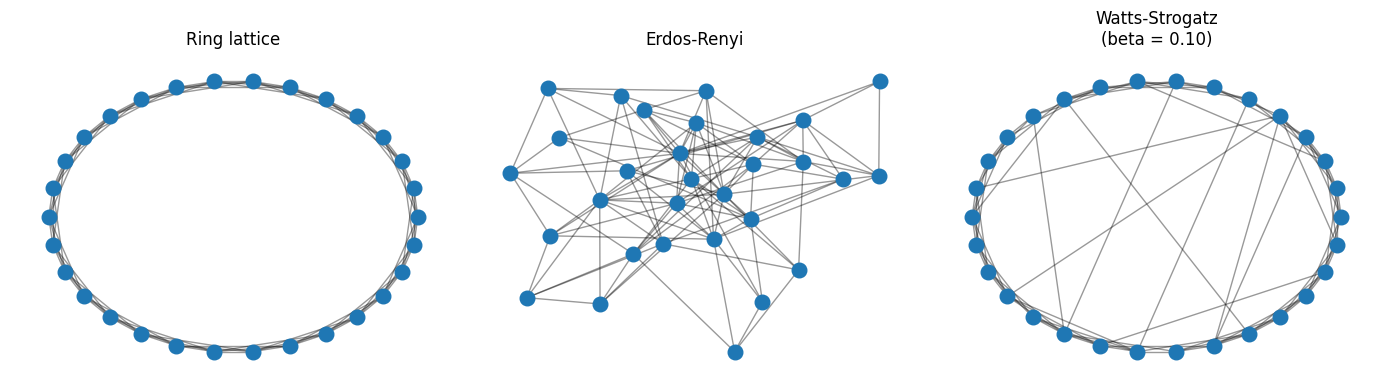

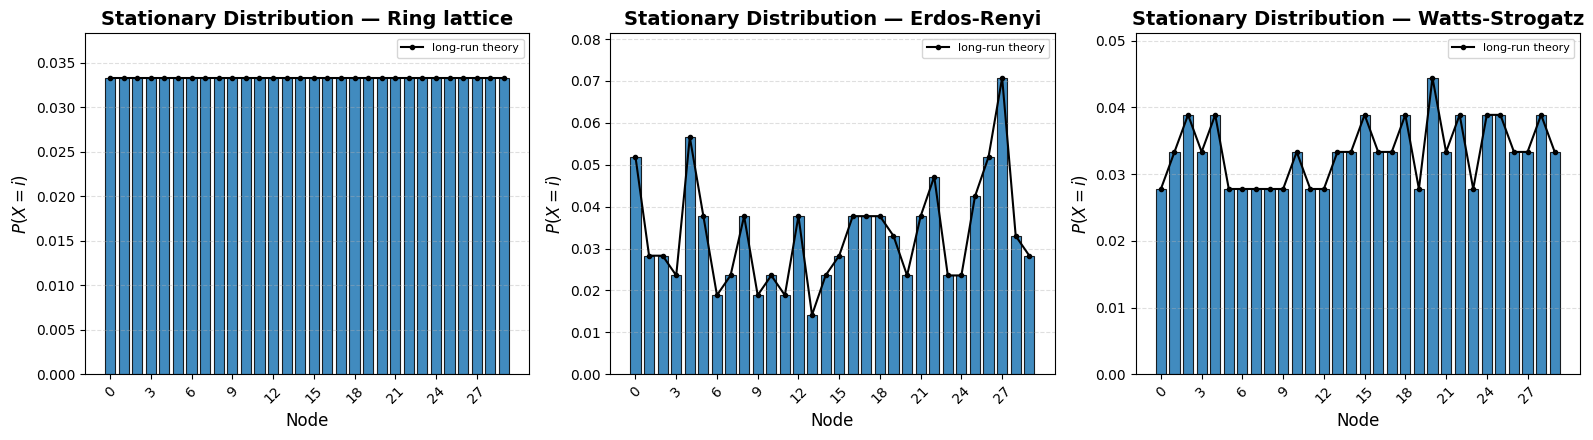

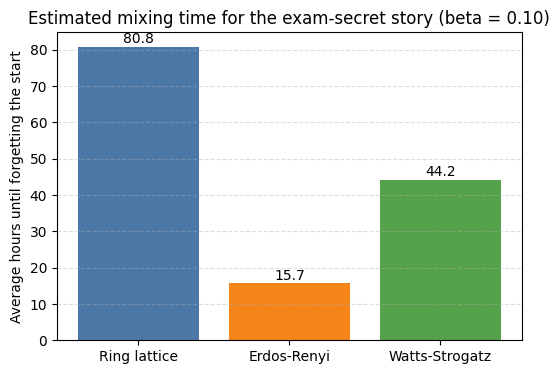

Average mixing time in the exam-secret story:
- Ring lattice: 80.77 hours
- Erdos-Renyi: 15.67 hours
- Watts-Strogatz: 44.20 hours


In [3]:
N, k = 30, 6
beta_to_try = 0.1  # change this value to test different WS rewiring levels
n_sims = 60
seed = 7

# Build the three networks with the same size and average degree.
# This way, the main visible difference comes from the structure.
graphs = build_all(N=N, k=k, beta=beta_to_try, seed=seed)

# If a random graph is disconnected, we keep its largest connected part.
# This avoids issues when simulating walks on isolated components.
graphs = {name: largest_component_graph(graph) for name, graph in graphs.items()}

# First, we visualize the three network shapes we are comparing.
fig = draw_networks_grid(
    graphs,
    titles={name: f"{MAPPING_NAMES[name]}\n(beta = {beta_to_try:.2f})" if name == "ws" else MAPPING_NAMES[name] for name in graphs},
    node_size=110,
    figsize=(14, 4),
    seed=seed,
)
plt.show()

summary = []
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# For each graph, we estimate the mixing time many times.
# Then we compare the empirical long-run distribution with the theoretical one.
for ax, (name, graph) in zip(axes, graphs.items()):
    out_dic, avg_iters = mixing_time(G=graph, n_simulations=n_sims, seed=seed)
    all_probs = np.array([run["distribution"] for run in out_dic.values()])
    exact_pi = stationary_distribution(graph)

    plot_mixing_time_distribution(all_probs, name_graph=MAPPING_NAMES[name], ax=ax)
    ax.plot(np.arange(len(exact_pi)), exact_pi, "o-", color="black", linewidth=1.5, markersize=3, label="long-run theory")
    
    # Show only some node labels on the x-axis so they do not overlap.
    tick_step = 3
    tick_positions = np.arange(0, len(exact_pi), tick_step)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_positions, rotation=45)
    ax.legend(fontsize=8)

    summary.append((name, avg_iters))

plt.show()

# This bar plot is a simple summary: smaller bar = faster loss of memory.
fig, ax = plt.subplots(figsize=(6, 4))
names = [MAPPING_NAMES[name] for name, _ in summary]
avg_values = [avg for _, avg in summary]
bars = ax.bar(names, avg_values, color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_ylabel("Average hours until forgetting the start")
ax.set_title(f"Estimated mixing time for the exam-secret story (beta = {beta_to_try:.2f})")
ax.grid(axis="y", linestyle="--", alpha=0.4)

for bar, value in zip(bars, avg_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.1f}", ha="center")

plt.show()

print("Average mixing time in the exam-secret story:")
for name, avg in summary:
    print(f"- {MAPPING_NAMES[name]}: {avg:.2f} hours")


## 4. Cover time

The **cover time** is the number of hours needed until every student has held the secret at least once.

Intuition:

- In a `ring`, the secret explores the class slowly because it only travels through nearby friendships.
- In `ws`, shortcuts help the secret reach distant parts of the class sooner.
- In `er`, the random connections often help cover the class faster.

In the next cell you can change `beta_selected` and also sweep several `beta` values to see how the average cover time changes. Intuitively, if we wanted each student of the class to have held at least once the exam in the least possible amount of time (minimum cover time), the connection should be at the same time local (so each cluster/group of friends are available to get the whole information) and random (each group has a popular friend which spread information with other group), but should not be extremely local (no information flows out of the group) or random (not each person of the local group may have had time to get the secret). There must be a balance!

Let's prove our intuition in the next cell:

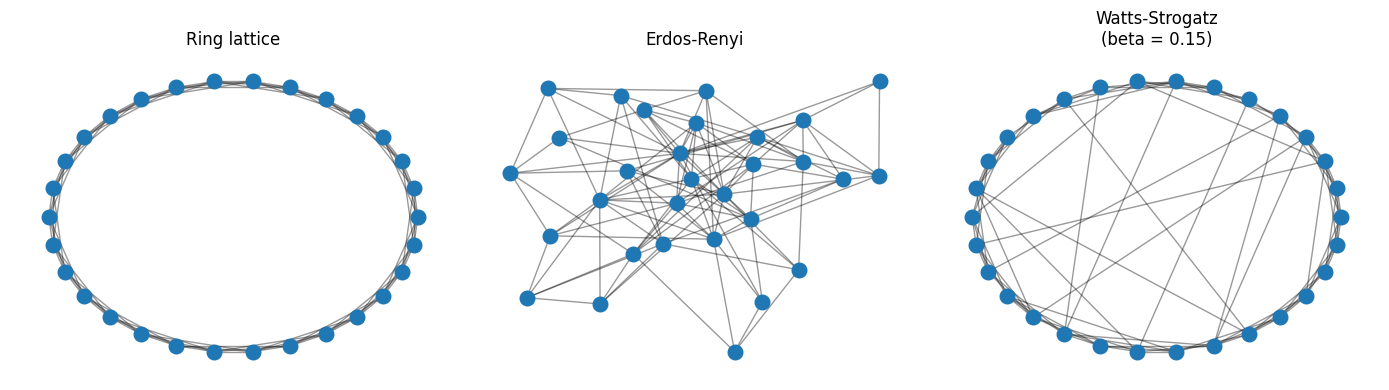

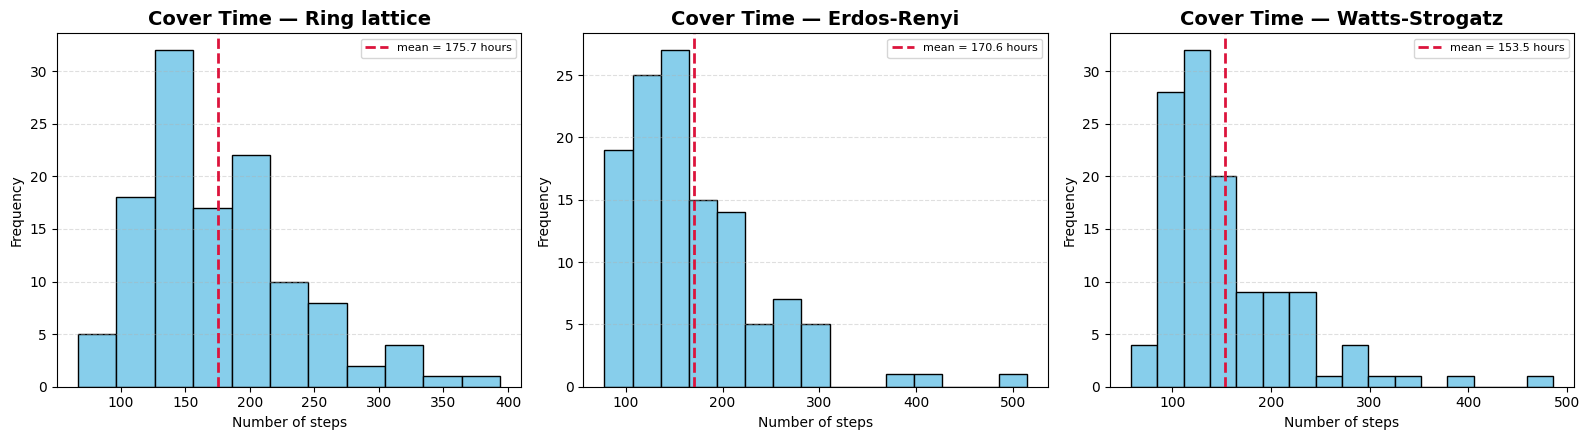

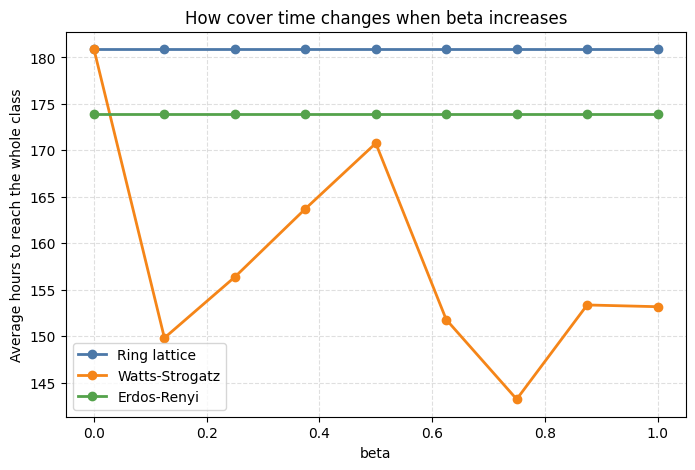

Average cover time in the exam-secret story for beta = 0.15:
- Ring lattice: 175.66 hours
- Erdos-Renyi: 170.63 hours
- Watts-Strogatz: 153.47 hours


In [4]:
N_cover, k_cover = 30, 6
beta_selected = 0.15  # change this value and rerun
beta_grid = np.linspace(0.0, 1.0, 9)
n_sims_cover = 120
seed = 7

# Again, we create the three graphs under the same global conditions.
graphs_cover = build_all(N=N_cover, k=k_cover, beta=beta_selected, seed=seed)

# We keep the largest connected component so the walk can really move around.
graphs_cover = {name: largest_component_graph(graph) for name, graph in graphs_cover.items()}

# Visual comparison of the three candidate class structures.
fig = draw_networks_grid(
    graphs_cover,
    titles={name: f"{MAPPING_NAMES[name]}\n(beta = {beta_selected:.2f})" if name == "ws" else MAPPING_NAMES[name] for name in graphs_cover},
    node_size=110,
    figsize=(14, 4),
    seed=seed,
)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
selected_cover = {}

# For each graph, we simulate many walks and record
# how long it takes until the secret has reached every student.
for ax, (name, graph) in zip(axes, graphs_cover.items()):
    steps_by_sim, avg_cover = cover_time(G=graph, n_simulations=n_sims_cover, seed=seed)
    plot_cover_time(steps_by_sim, MAPPING_NAMES[name], ax=ax)
    ax.axvline(avg_cover, color="crimson", linestyle="--", linewidth=2, label=f"mean = {avg_cover:.1f} hours")
    ax.legend(fontsize=8)
    selected_cover[name] = avg_cover

plt.show()

cover_curves = {name: [] for name in ["ring", "ws", "er"]}

# Now we repeat the experiment for several beta values.
# This lets us see how adding shortcuts changes the average cover time.
for beta in beta_grid:
    beta_graphs = build_all(N=N_cover, k=k_cover, beta=float(beta), seed=seed)
    beta_graphs = {name: largest_component_graph(graph) for name, graph in beta_graphs.items()}

    for name, graph in beta_graphs.items():
        _, avg_cover = cover_time(G=graph, n_simulations=80, seed=seed)
        cover_curves[name].append(avg_cover)

# Final summary plot: it shows how the average cover time evolves with beta.
fig, ax = plt.subplots(figsize=(8, 5))
for name, color in zip(["ring", "ws", "er"], ["#4C78A8", "#F58518", "#54A24B"]):
    ax.plot(beta_grid, cover_curves[name], marker="o", linewidth=2, label=MAPPING_NAMES[name], color=color)

ax.set_xlabel("beta")
ax.set_ylabel("Average hours to reach the whole class")
ax.set_title("How cover time changes when beta increases")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()
plt.show()

print(f"Average cover time in the exam-secret story for beta = {beta_selected:.2f}:")
for name, avg_cover in selected_cover.items():
    print(f"- {MAPPING_NAMES[name]}: {avg_cover:.2f} hours")
